<a href="https://colab.research.google.com/github/oanailies/EmotionDetection-ViT-FER2025/blob/main/EmotionDetection4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import json
import contextlib
import shutil
import tarfile
import hashlib
from pathlib import Path

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.transforms import InterpolationMode
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit

!pip -q install huggingface_hub
from huggingface_hub import hf_hub_download


In [ ]:
# ---------------------------------------------
# 2. MOUNT GOOGLE DRIVE (ONLY FOR SAVING MODELS/CHECKPOINTS)
# ---------------------------------------------
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# ---------------------------------------------
# 3. DOWNLOAD FER2025 (DIRECT) + BUILD IMAGEFOLDER STRUCTURE (TRAIN/TEST)
# ---------------------------------------------
HF_REPO = "imadhavan/FER2025"

LOCAL_TAR_DIR = "/content/fer2025_tars"
RAW_DIR = "/content/fer2025_raw"
LOCAL_DATASET_ROOT = "/content/fer2025_archive"

train_path = os.path.join(LOCAL_DATASET_ROOT, "train")
test_path  = os.path.join(LOCAL_DATASET_ROOT, "test")

os.makedirs(LOCAL_TAR_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

CLASS_TARS = {
    "angry":    "Angry.tar",
    "disgust":  "Disgust.tar",
    "fear":     "Fear.tar",
    "happy":    "Happy.tar",
    "neutral":  "Neutral.tar",
    "sad":      "Sad.tar",
    "surprise": "Surprise.tar",
}

def _sha_bucket(s: str, seed: int = 42) -> int:
    h = hashlib.sha1((str(seed) + s).encode("utf-8")).hexdigest()
    return int(h[:8], 16) % 100

def _ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def _safe_symlink(src, dst):
    if os.path.exists(dst):
        return
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

READY_FLAG = os.path.join(LOCAL_DATASET_ROOT, ".READY")
if os.path.exists(READY_FLAG):
    print("FER2025 ImageFolder already prepared. Skipping rebuild.")
else:
    print("Downloading TARs from HuggingFace...")
    tar_paths = {}
    for cls, tar_name in CLASS_TARS.items():
        p = hf_hub_download(
            repo_id=HF_REPO,
            filename=tar_name,
            repo_type="dataset",
            cache_dir=LOCAL_TAR_DIR
        )
        tar_paths[cls] = p
        print(cls, "->", p)

    print("\nExtracting TARs...")
    for cls, tar_p in tar_paths.items():
        cls_raw_dir = os.path.join(RAW_DIR, cls)
        _ensure_dir(cls_raw_dir)

        with tarfile.open(tar_p, "r") as tf:
            tf.extractall(cls_raw_dir)

        print("Extracted:", cls, "->", cls_raw_dir)

    print("\nBuilding train/test folders (deterministic split by filename hash)...")
    for cls in CLASS_TARS.keys():
        _ensure_dir(os.path.join(train_path, cls))
        _ensure_dir(os.path.join(test_path, cls))

        cls_raw_dir = Path(os.path.join(RAW_DIR, cls))
        files = []
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
            files.extend(list(cls_raw_dir.rglob(ext)))

        if len(files) == 0:
            raise RuntimeError(f"No images found after extraction for class: {cls}")

        for f in files:
            f_str = str(f)
            b = _sha_bucket(f.name, seed=42)  # stable split
            split = "train" if b < 85 else "test"  # 85/15
            out_dir = train_path if split == "train" else test_path

            dst = os.path.join(out_dir, cls, f.name)
            _safe_symlink(f_str, dst)

        print(f"{cls}: total={len(files)} -> train/test prepared")

    with open(READY_FLAG, "w") as f:
        f.write("ok")

print("Train path:", train_path)
print("Test path :", test_path)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Angry.tar:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

angry -> /content/fer2025_tars/datasets--imadhavan--FER2025/snapshots/e240b900b0cf1ea20e1913d8a4755812617d595e/Angry.tar


Disgust.tar:   0%|          | 0.00/1.49G [00:00<?, ?B/s]

disgust -> /content/fer2025_tars/datasets--imadhavan--FER2025/snapshots/e240b900b0cf1ea20e1913d8a4755812617d595e/Disgust.tar


...

sad -> /content/fer2025_tars/datasets--imadhavan--FER2025/snapshots/e240b900b0cf1ea20e1913d8a4755812617d595e/Sad.tar


Surprise.tar:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

surprise -> /content/fer2025_tars/datasets--imadhavan--FER2025/snapshots/e240b900b0cf1ea20e1913d8a4755812617d595e/Surprise.tar

Extracting TARs...


/tmp/ipython-input-3753128723.py:65: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(cls_raw_dir)


Extracted: angry -> /content/fer2025_raw/angry
Extracted: disgust -> /content/fer2025_raw/disgust
Extracted: fear -> /content/fer2025_raw/fear
Extracted: happy -> /content/fer2025_raw/happy
Extracted: neutral -> /content/fer2025_raw/neutral
Extracted: sad -> /content/fer2025_raw/sad
Extracted: surprise -> /content/fer2025_raw/surprise

Building train/test folders (deterministic split by filename hash)...
angry: total=224624 -> train/test prepared
disgust: total=239366 -> train/test prepared
fear: total=223466 -> train/test prepared
happy: total=222082 -> train/test prepared
neutral: total=234230 -> train/test prepared
sad: total=217884 -> train/test prepared
surprise: total=228158 -> train/test prepared
Train path: /content/fer2025_archive/train
Test path : /content/fer2025_archive/test


In [ ]:
# ---------------------------------------------
# 4. IMAGE TRANSFORMS (SAFE AUGMENTATION)
# ---------------------------------------------
IMG_SIZE = 48

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAutocontrast(p=0.4),
    transforms.RandomEqualize(p=0.15),
    transforms.RandomAffine(degrees=7, translate=(0.04, 0.04), scale=(0.95, 1.05), fill=128),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.08, scale=(0.02, 0.05), ratio=(0.3, 3.3), value=0.5),
    transforms.Normalize((0.5,), (0.5,)),
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


In [ ]:
# ---------------------------------------------
# 5. LOAD DATASET
# ---------------------------------------------
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_path,  transform=test_transform)

classes = train_dataset.classes

print("CLASSES:", classes)
print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(test_dataset))

train_dataset_no_aug = datasets.ImageFolder(
    train_path,
    transform=transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)


CLASSES: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of training images: 1351613
Number of testing images: 238197


In [ ]:
# ---------------------------------------------
# 6. CREATE DATALOADERS (OPTIMIZED)
# ---------------------------------------------
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images_sample, labels_sample = next(iter(train_loader))
print("Sanity check - batch shape:", images_sample.shape)


Sanity check - batch shape: torch.Size([64, 1, 48, 48])


In [ ]:
# ---------------------------------------------
# 7. FUNCTION TO SHOW A SINGLE IMAGE
# ---------------------------------------------
def show_img(tensor_img, title=""):
    img = tensor_img.squeeze().numpy()
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")


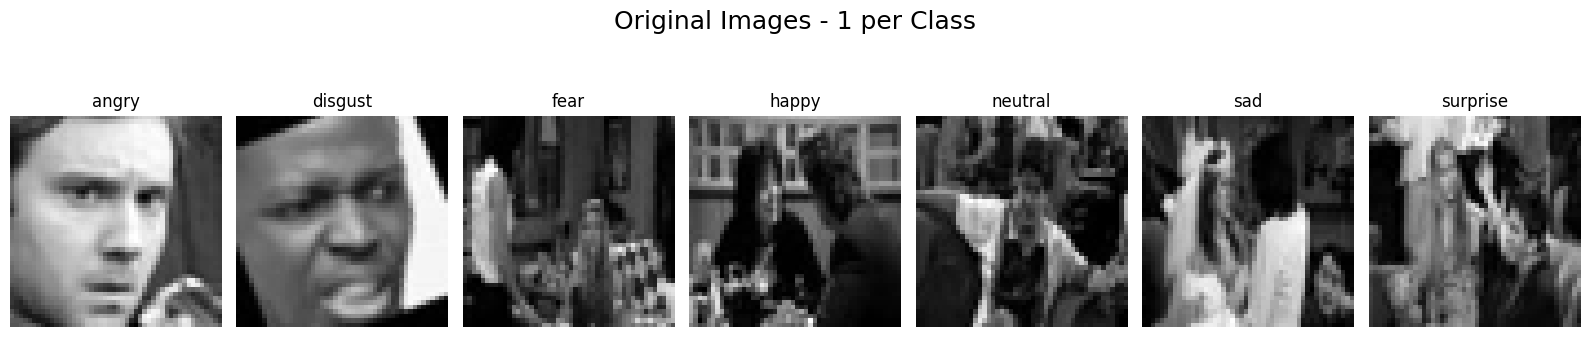

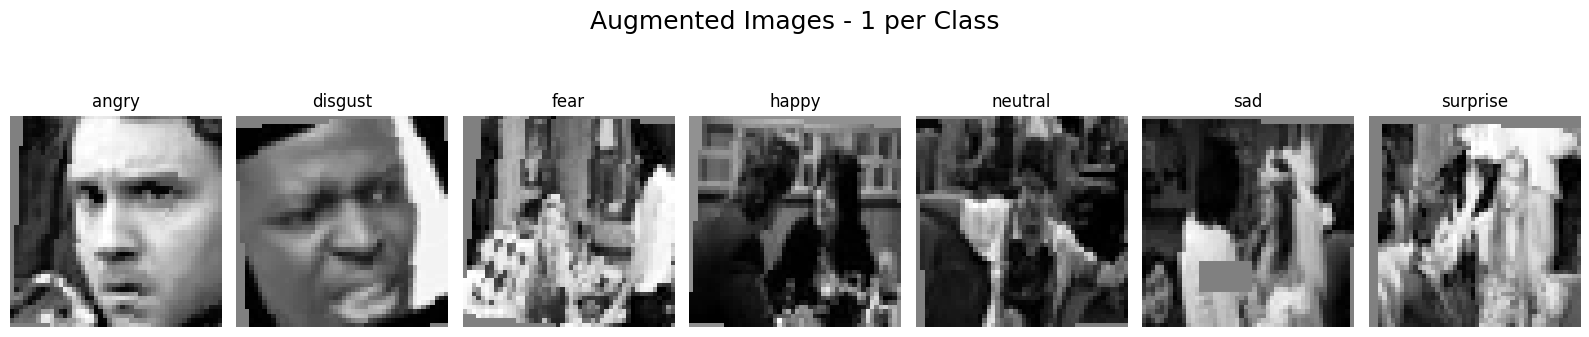

In [ ]:
# ---------------------------------------------
# 8A. ORIGINAL IMAGES
# ---------------------------------------------
plt.figure(figsize=(16, 4))
num_classes = len(classes)

for i, cls in enumerate(classes):
    for idx, (img_path, label) in enumerate(train_dataset_no_aug.samples):
        if label == i:
            img, label_img = train_dataset_no_aug[idx]
            plt.subplot(1, num_classes, i + 1)
            show_img(img, f"{classes[label_img]}")
            break

plt.suptitle("Original Images - 1 per Class", fontsize=18)
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 8B. AUGMENTED IMAGES
# ---------------------------------------------
plt.figure(figsize=(16, 4))

for i, cls in enumerate(classes):
    for idx, (img_path, label) in enumerate(train_dataset.samples):
        if label == i:
            img, label_img = train_dataset[idx]
            plt.subplot(1, num_classes, i + 1)
            show_img(img, f"{classes[label_img]}")
            break

plt.suptitle("Augmented Images - 1 per Class", fontsize=18)
plt.tight_layout()
plt.show()


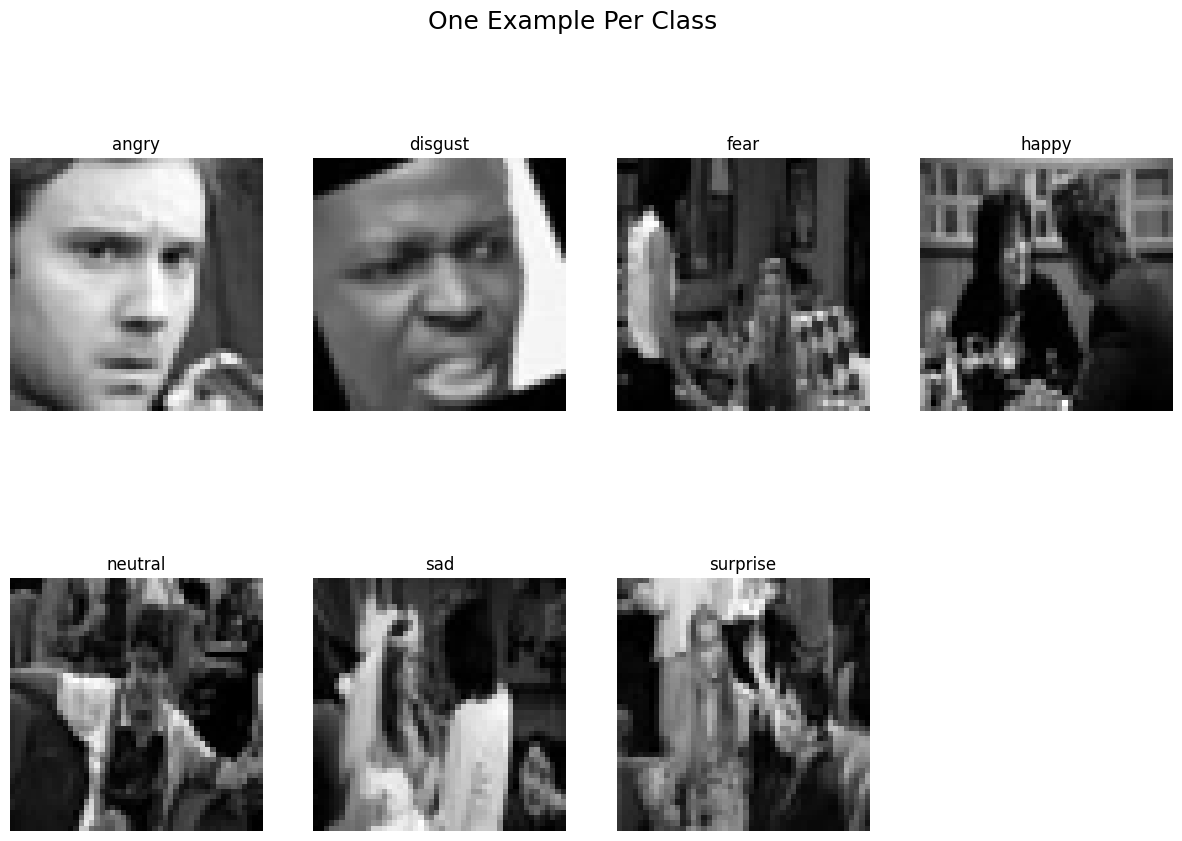

In [ ]:
# ---------------------------------------------
# 9. SHOW SAMPLE IMAGES PER CLASS
# ---------------------------------------------
viz_dataset = datasets.ImageFolder(train_path, transform=test_transform)

first_per_class = {}
for img, label in viz_dataset:
    class_name = classes[label]
    if class_name not in first_per_class:
        first_per_class[class_name] = img
    if len(first_per_class) == len(classes):
        break

plt.figure(figsize=(15, 10))
for idx, cls in enumerate(classes):
    plt.subplot(2, 4, idx + 1)
    show_img(first_per_class[cls], cls)

plt.suptitle("One Example Per Class", fontsize=18)
plt.show()


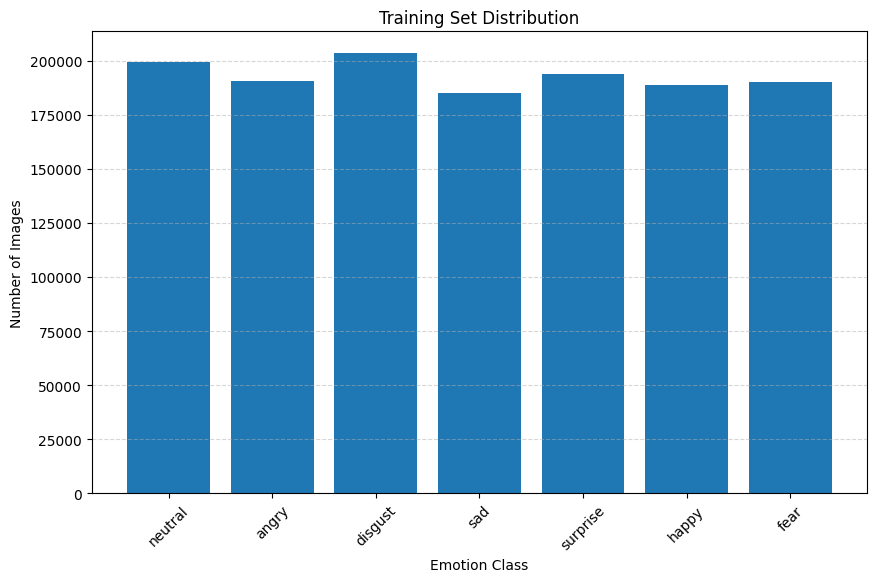

neutral: 199372 images
angry: 190792 images
disgust: 203354 images
sad: 185222 images
surprise: 194043 images
happy: 188772 images
fear: 190058 images


In [ ]:
# ---------------------------------------------
# 10. BAR CHART WITH DISTRIBUTION OF IMAGES
# ---------------------------------------------
class_counts = {}
for path, _, files in os.walk(train_path):
    label = os.path.basename(path)
    if label in classes:
        class_counts[label] = len(files)

plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.title("Training Set Distribution")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")


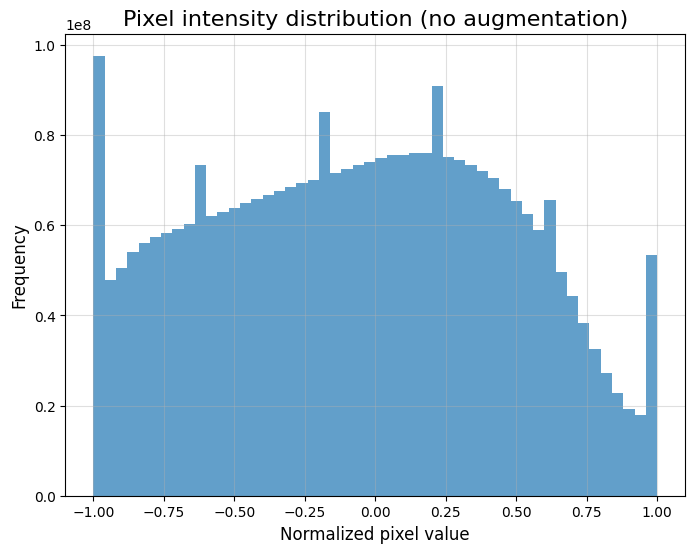

In [ ]:
# ---------------------------------------------
# 11. PIXEL INTENSITY HISTOGRAM
# ---------------------------------------------
BINS = 50
MIN_VAL, MAX_VAL = -1.0, 1.0

transform_fara_aug = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

if isinstance(train_dataset, Subset):
    root = train_dataset.dataset.root
    dataset_fara_aug = datasets.ImageFolder(root=root, transform=transform_fara_aug)
    train_dataset_fara_aug = Subset(dataset_fara_aug, train_dataset.indices)
else:
    root = train_dataset.root
    train_dataset_fara_aug = datasets.ImageFolder(root=root, transform=transform_fara_aug)

hist_loader = DataLoader(
    train_dataset_fara_aug,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

hist = torch.zeros(BINS, dtype=torch.float64)
with torch.no_grad():
    for imgs, _ in hist_loader:
        hist += torch.histc(imgs, bins=BINS, min=MIN_VAL, max=MAX_VAL).double()

bin_edges = np.linspace(MIN_VAL, MAX_VAL, BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
bin_width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(8, 6))
plt.bar(bin_centers, hist.numpy(), width=bin_width, alpha=0.7)
plt.title("Pixel intensity distribution (no augmentation)", fontsize=16)
plt.xlabel("Normalized pixel value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.4)
plt.show()


In [ ]:
# ---------------------------------------------
# 12. VISION TRANSFORMER PARAMETERS (OPTIMIZED)
# ---------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

PATCH_SIZE = 4
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

EMBED_DIM = 256
NUM_HEADS = 4
DEPTH = 6
MLP_DIM = 512
DROPOUT = 0.10

NUM_CLASSES = len(classes)

EPOCHS = 45
BATCH_SIZE = 64
LR = 2e-4
WEIGHT_DECAY = 1e-2
CLIP_NORM = 1.0
VAL_RATIO = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")

def make_grad_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler(enabled=enabled)
    except Exception:
        from torch.cuda.amp import GradScaler
        return GradScaler(enabled=enabled)

scaler = make_grad_scaler(use_amp)

print("Device:", device, "| AMP:", use_amp)
print("Classes:", classes)


Device: cuda | AMP: True
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# ---------------------------------------------
# 13. TRAIN / VALIDATION SPLIT + DATALOADERS
# ---------------------------------------------
base_dataset = datasets.ImageFolder(train_path, transform=None)
targets = np.array([y for _, y in base_dataset.samples], dtype=np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_RATIO, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

train_dataset_split = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_split   = datasets.ImageFolder(train_path, transform=test_transform)

train_data = Subset(train_dataset_split, train_idx)
val_data   = Subset(val_dataset_split, val_idx)

pin = torch.cuda.is_available()
num_workers = min(4, os.cpu_count() or 2) if pin else 0

g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin,
    generator=g,
    drop_last=True,
)

val_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin,
)

test_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin,
)

if num_workers > 0:
    extra = dict(
        persistent_workers=True,
        prefetch_factor=2,
        worker_init_fn=seed_worker,
    )
    train_kwargs.update(extra)
    val_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))
    test_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))
else:
    train_kwargs.update(dict(worker_init_fn=None))

train_loader = DataLoader(train_data, **train_kwargs)
val_loader   = DataLoader(val_data, **val_kwargs)
test_loader  = DataLoader(test_dataset, **test_kwargs)

images_sample, labels_sample = next(iter(train_loader))
print("Sanity check - train batch shape:", images_sample.shape)


Sanity check - train batch shape: torch.Size([64, 1, 48, 48])


In [ ]:
# ---------------------------------------------
# 14. PATCH EMBEDDING
# ---------------------------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM):
        super().__init__()
        self.projection = nn.Conv2d(
            in_channels=1,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


In [ ]:
# ---------------------------------------------
# 15. POSITIONAL ENCODING
# ---------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, num_patches=NUM_PATCHES, embed_dim=EMBED_DIM):
        super().__init__()
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim) * 0.02
        )

    def forward(self, x):
        return x + self.pos_embedding[:, : x.size(1), :]


In [ ]:
# ---------------------------------------------
# 16. TRANSFORMER ENCODER BLOCK
# ---------------------------------------------
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_dim=MLP_DIM, dropout=DROPOUT):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x, need_weights=False)
        x = self.norm1(x + attn_output)
        x = self.norm2(x + self.mlp(x))
        return x


In [ ]:
# ---------------------------------------------
# 17. VISION TRANSFORMER MODEL
# ---------------------------------------------
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.patch_embed = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1, 1, EMBED_DIM) * 0.02)
        self.pos_embed = PositionalEncoding()

        self.pos_drop = nn.Dropout(DROPOUT)
        self.transformer = nn.Sequential(*[TransformerBlock() for _ in range(DEPTH)])
        self.norm = nn.LayerNorm(EMBED_DIM)

        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, EMBED_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(EMBED_DIM, NUM_CLASSES),
        )

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_embed(x)
        x = self.pos_drop(x)

        x = self.transformer(x)
        x = self.norm(x)

        cls_out = x[:, 0]
        tok_mean = x[:, 1:].mean(dim=1)
        feat = 0.5 * cls_out + 0.5 * tok_mean

        return self.head(feat)

model = VisionTransformer().to(device)
print(model)


VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(1, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_embed): PositionalEncoding()
  (pos_drop): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=256, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True

In [ ]:
# ---------------------------------------------
# 18. OPTIMIZE (TRAINING + FINE-TUNING SAFE)
# ---------------------------------------------
from torch import nn, optim
import inspect

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# -----------------------------
# Fine-tuning configuration
# -----------------------------
FINE_TUNE_START_EPOCH = 46
FINE_TUNE_LR = 5e-5

# -----------------------------
# Optimizer (initial – normal training)
# -----------------------------
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

# -----------------------------
# Scheduler (shared, reset-safe)
# -----------------------------
plateau_kwargs = dict(
    mode="min",
    factor=0.5,
    patience=2,
    threshold=1e-3,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6
)

if "verbose" in inspect.signature(optim.lr_scheduler.ReduceLROnPlateau).parameters:
    plateau_kwargs["verbose"] = True

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    **plateau_kwargs
)


In [ ]:
# ---------------------------------------------
# 19. TRAIN (FINAL + FINE-TUNING + BEST MODEL)
# ---------------------------------------------
import os
import time
import json
import contextlib
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from torch import optim

RUN_TAG = "FER2025_VIT_V1"

BEST_MODEL_PATH = f"/content/drive/MyDrive/best_vit_model_{RUN_TAG}_by_val_loss.pth"
BEST_CKPT_PATH  = f"/content/drive/MyDrive/best_vit_ckpt_{RUN_TAG}_by_val_loss.pth"
CHECKPOINT_PATH = f"/content/drive/MyDrive/checkpoint_vit_{RUN_TAG}.pth"
METRICS_PATH    = f"/content/drive/MyDrive/training_metrics_{RUN_TAG}.json"

# -----------------------------
# Fine-tuning setup
# -----------------------------
FINE_TUNE_START_EPOCH = 46
FINE_TUNE_EPOCHS = 2
FINE_TUNE_LR = 5e-5
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

use_amp = (device.type == "cuda")
scaler = make_grad_scaler(use_amp)

# -----------------------------
# Utils
# -----------------------------
def _autocast():
    if not use_amp:
        return contextlib.nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", enabled=True)
    except Exception:
        from torch.cuda.amp import autocast
        return autocast(enabled=True)

def _atomic_torch_save(obj, path):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)

def _optimizer_to(optim_obj, dev):
    for state in optim_obj.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(dev)

# -----------------------------
# Train / Eval
# -----------------------------
def train_one_epoch(model_obj, loader):
    model_obj.train()
    total_loss, seen, correct = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with _autocast():
            outputs = model_obj(images)
            loss = criterion(outputs, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_obj.parameters(), CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_obj.parameters(), CLIP_NORM)
            optimizer.step()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        seen += bs
        correct += (outputs.argmax(dim=1) == labels).sum().item()

    return total_loss / seen, 100.0 * correct / seen

@torch.inference_mode()
def evaluate(model_obj, loader):
    model_obj.eval()
    total_loss, seen, correct = 0.0, 0, 0
    preds_all, labels_all = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with _autocast():
            outputs = model_obj(images)
            loss = criterion(outputs, labels)

        bs = labels.size(0)
        total_loss += loss.item() * bs
        seen += bs

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        preds_all.append(preds.cpu())
        labels_all.append(labels.cpu())

    y_pred = torch.cat(preds_all).numpy()
    y_true = torch.cat(labels_all).numpy()

    return (
        total_loss / seen,
        100.0 * correct / seen,
        precision_score(y_true, y_pred, average="macro", zero_division=0),
        recall_score(y_true, y_pred, average="macro", zero_division=0),
        f1_score(y_true, y_pred, average="macro", zero_division=0),
    )

# -----------------------------
# Optimizer & Scheduler (initial)
# -----------------------------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

# -----------------------------
# Resume
# -----------------------------
start_epoch = 1
history = {}
best_val_loss = float("inf")
best_epoch = -1

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    _optimizer_to(optimizer, device)

    if use_amp and ckpt.get("scaler_state"):
        scaler.load_state_dict(ckpt["scaler_state"])

    history = {int(k): v for k, v in ckpt.get("history", {}).items()}
    start_epoch = ckpt["epoch"] + 1

    for ep, m in history.items():
        if m.get("val_loss", float("inf")) < best_val_loss:
            best_val_loss = m["val_loss"]
            best_epoch = ep

    print(f"Resumed from checkpoint. Next epoch: {start_epoch}")
    print(f"Current best epoch: {best_epoch} | val_loss={best_val_loss:.4f}")

# -----------------------------
# Train loop
# -----------------------------
print("Starting training...")
start_time = time.time()

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):

    if epoch == FINE_TUNE_START_EPOCH:
        optimizer = optim.AdamW(
            model.parameters(),
            lr=FINE_TUNE_LR,
            weight_decay=WEIGHT_DECAY
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
        )
        print(f"\n>>> FINE-TUNING ACTIVE @ epoch {epoch} | lr={FINE_TUNE_LR} <<<\n")

    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_p, va_r, va_f1 = evaluate(model, val_loader)

    scheduler.step(va_loss)

    history.setdefault(epoch, {})
    history[epoch].update({
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": va_loss,
        "val_acc": va_acc,
        "val_p": va_p,
        "val_r": va_r,
        "val_f1": va_f1,
    })

    # -----------------------------
    # SAVE BEST MODEL
    # -----------------------------
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_epoch = epoch

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        _atomic_torch_save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "scaler_state": scaler.state_dict() if use_amp else None,
            "history": history,
        }, BEST_CKPT_PATH)

        print(f">>> NEW BEST MODEL @ epoch {epoch} | val_loss={va_loss:.4f} <<<")

    # -----------------------------
    # SAVE CHECKPOINT
    # -----------------------------
    _atomic_torch_save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict() if use_amp else None,
        "history": history,
    }, CHECKPOINT_PATH)

    elapsed = (time.time() - start_time) / 60
    print(
        f"Epoch {epoch:02d}/{TOTAL_EPOCHS} | "
        f"train loss: {tr_loss:.4f}, train acc: {tr_acc:.2f}% | "
        f"val loss: {va_loss:.4f}, val acc: {va_acc:.2f}% | "
        f"F1: {va_f1:.4f} | time: {elapsed:.1f} min"
    )

# -----------------------------
# Save metrics
# -----------------------------
with open(METRICS_PATH, "w") as f:
    json.dump(history, f, indent=2)

print("\nTraining finished.")
print(f"BEST MODEL: epoch {best_epoch} | val_loss={best_val_loss:.4f}")


Resumed from checkpoint. Next epoch: 46
Current best epoch: 43 | val_loss=0.5688
Starting training...

>>> FINE-TUNING ACTIVE @ epoch 46 | lr=5e-05 <<<

>>> NEW BEST MODEL @ epoch 46 | val_loss=0.5050 <<<
Epoch 46/47 | train loss: 0.3701, train acc: 95.90% | val loss: 0.5050, val acc: 91.24% | F1: 0.9119 | time: 42.3 min
>>> NEW BEST MODEL @ epoch 47 | val_loss=0.4792 <<<
Epoch 47/47 | train loss: 0.4230, train acc: 93.49% | val loss: 0.4792, val acc: 91.90% | F1: 0.9186 | time: 81.3 min

Training finished.
BEST MODEL: epoch 47 | val_loss=0.4792


In [ ]:
print("\n========== FULL TRAINING HISTORY ==========\n")

for ep in sorted(history.keys()):
    m = history[ep]

    tag = ""
    if ep == best_epoch:
        tag = "  <<< BEST VAL LOSS >>>"
    if ep == best_f1_epoch:
        tag += "  <<< BEST F1 >>>"

    print(
        f"Epoch {ep:02d} | "
        f"train loss: {m['train_loss']:.4f}, train acc: {m['train_acc']:.2f}% | "
        f"val loss: {m['val_loss']:.4f}, val acc: {m['val_acc']:.2f}% | "
        f"val F1: {m['val_f1']:.4f}"
        f"{tag}"
    )

print("\n==========================================\n")



========== FULL TRAINING HISTORY ==========

Epoch 01 | train loss: 1.7129, train acc: 32.84% | val loss: 1.4760, val acc: 45.11% | val F1: 0.4389
Epoch 02 | train loss: 1.4562, train acc: 46.40% | val loss: 1.3158, val acc: 53.04% | val F1: 0.5211
Epoch 03 | train loss: 1.3350, train acc: 52.22% | val loss: 1.2161, val acc: 57.65% | val F1: 0.5748
Epoch 04 | train loss: 1.2570, train acc: 55.91% | val loss: 1.1737, val acc: 60.17% | val F1: 0.6036
Epoch 05 | train loss: 1.1964, train acc: 58.73% | val loss: 1.1064, val acc: 63.11% | val F1: 0.6322
Epoch 06 | train loss: 1.1441, train acc: 61.23% | val loss: 1.0439, val acc: 65.76% | val F1: 0.6577
Epoch 07 | train loss: 1.0952, train acc: 63.54% | val loss: 0.9853, val acc: 68.52% | val F1: 0.6834
Epoch 08 | train loss: 1.0208, train acc: 67.05% | val loss: 0.9373, val acc: 70.91% | val F1: 0.7084
Epoch 09 | train loss: 1.0176, train acc: 67.24% | val loss: 0.9183, val acc: 71.69% | val F1: 0.7179
Epoch 10 | train loss: 0.9762, train

In [ ]:
all_preds = []
all_labels = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)


In [ ]:
test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average="macro")
test_recall = recall_score(y_true, y_pred, average="macro")
test_f1 = f1_score(y_true, y_pred, average="macro")

print("\n===== TEST SET PERFORMANCE =====")
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")


In [ ]:
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
))



===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

       angry     0.9355    0.9276    0.9315     33832
     disgust     0.9552    0.9786    0.9668     36012
        fear     0.9174    0.9405    0.9288     33408
       happy     0.9359    0.9019    0.9186     33310
     neutral     0.8654    0.8533    0.8593     34858
         sad     0.8791    0.9001    0.8894     32662
    surprise     0.9432    0.9288    0.9359     34115

    accuracy                         0.9191    238197
   macro avg     0.9188    0.9187    0.9186    238197
weighted avg     0.9191    0.9191    0.9190    238197



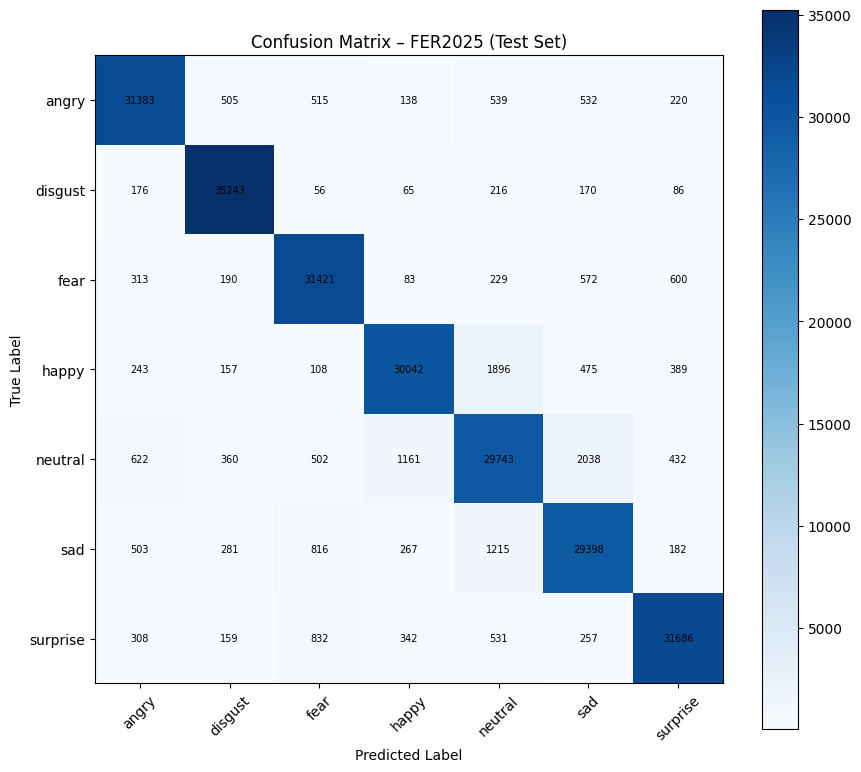

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix – FER2025 (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)

plt.colorbar()
plt.tight_layout()
plt.show()


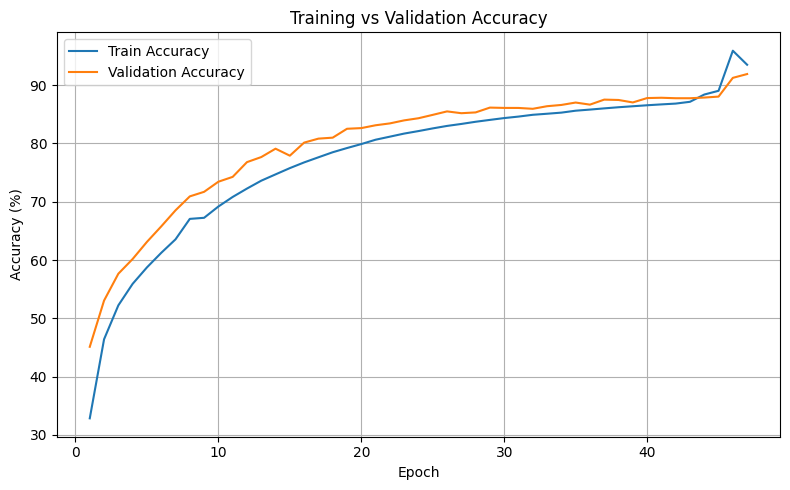

In [ ]:
train_acc = [history[e]["train_acc"] for e in sorted(history)]
val_acc   = [history[e]["val_acc"] for e in sorted(history)]
epochs    = sorted(history)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


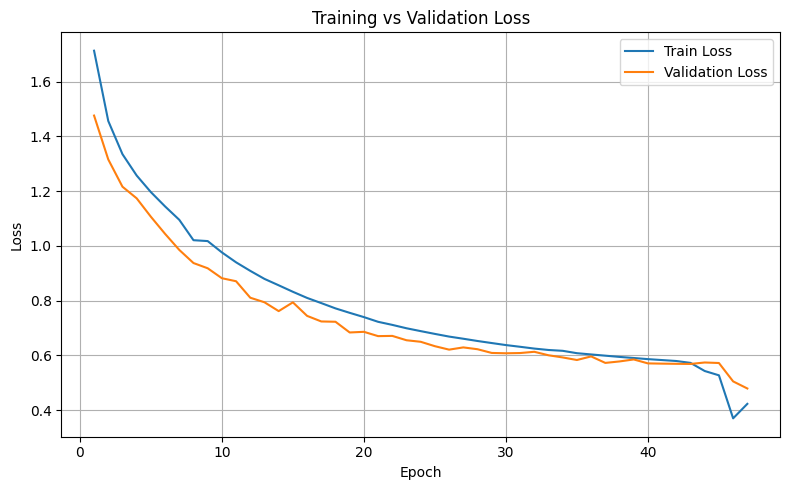

In [ ]:
train_loss = [history[e]["train_loss"] for e in sorted(history)]
val_loss   = [history[e]["val_loss"] for e in sorted(history)]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


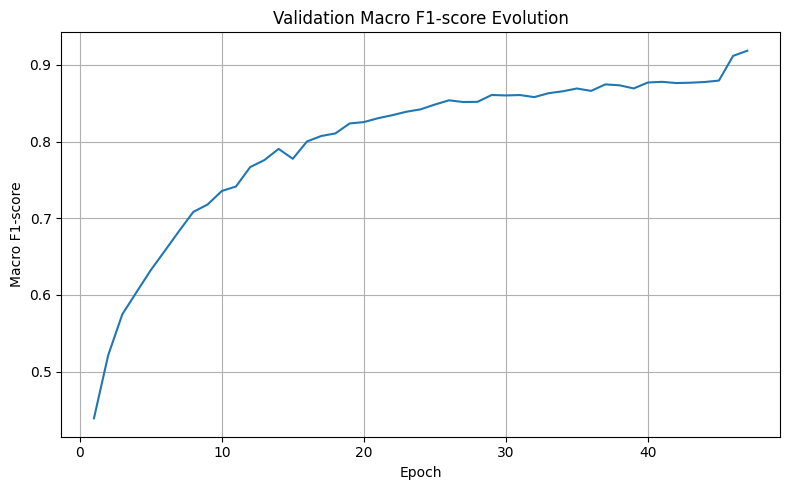

In [ ]:
val_f1 = [history[e]["val_f1"] for e in sorted(history)]

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_f1)
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Validation Macro F1-score Evolution")
plt.grid(True)
plt.tight_layout()
plt.show()


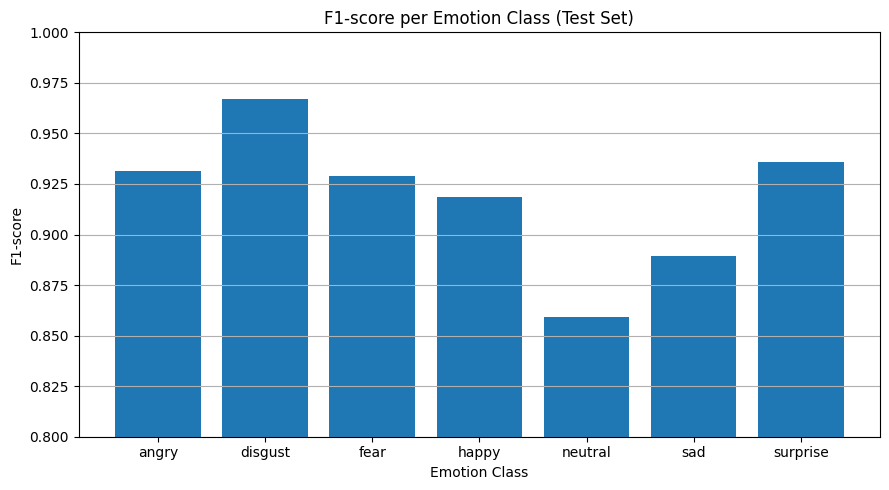

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true, y_pred, target_names=classes, output_dict=True
)

f1_per_class = [report[c]["f1-score"] for c in classes]

plt.figure(figsize=(9, 5))
plt.bar(classes, f1_per_class)
plt.ylim(0.8, 1.0)
plt.xlabel("Emotion Class")
plt.ylabel("F1-score")
plt.title("F1-score per Emotion Class (Test Set)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


In [ ]:
y_true = []
y_pred = []
images_all = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        images_all.extend(images.cpu())


In [ ]:
correct_idx = [i for i in range(len(y_true)) if y_true[i] == y_pred[i]]
wrong_idx   = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]

print("Correct predictions:", len(correct_idx))
print("Wrong predictions  :", len(wrong_idx))


Correct predictions: 33327
Wrong predictions  : 204870


In [ ]:
import matplotlib.pyplot as plt
import random

def show_correct_predictions(images, y_true, y_pred, classes, n=12):
    idxs = random.sample(correct_idx, n)

    rows = 3
    cols = 4

    plt.figure(figsize=(24, 18))

    for i, idx in enumerate(idxs):
        img = images[idx].squeeze()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        plt.title(
            f"Pred: {classes[y_pred[idx]]}\nTrue: {classes[y_true[idx]]}",
            color="green",
            fontsize=16
        )

    plt.suptitle("Correct Predictions – FER2025 (Test Set)", fontsize=26)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


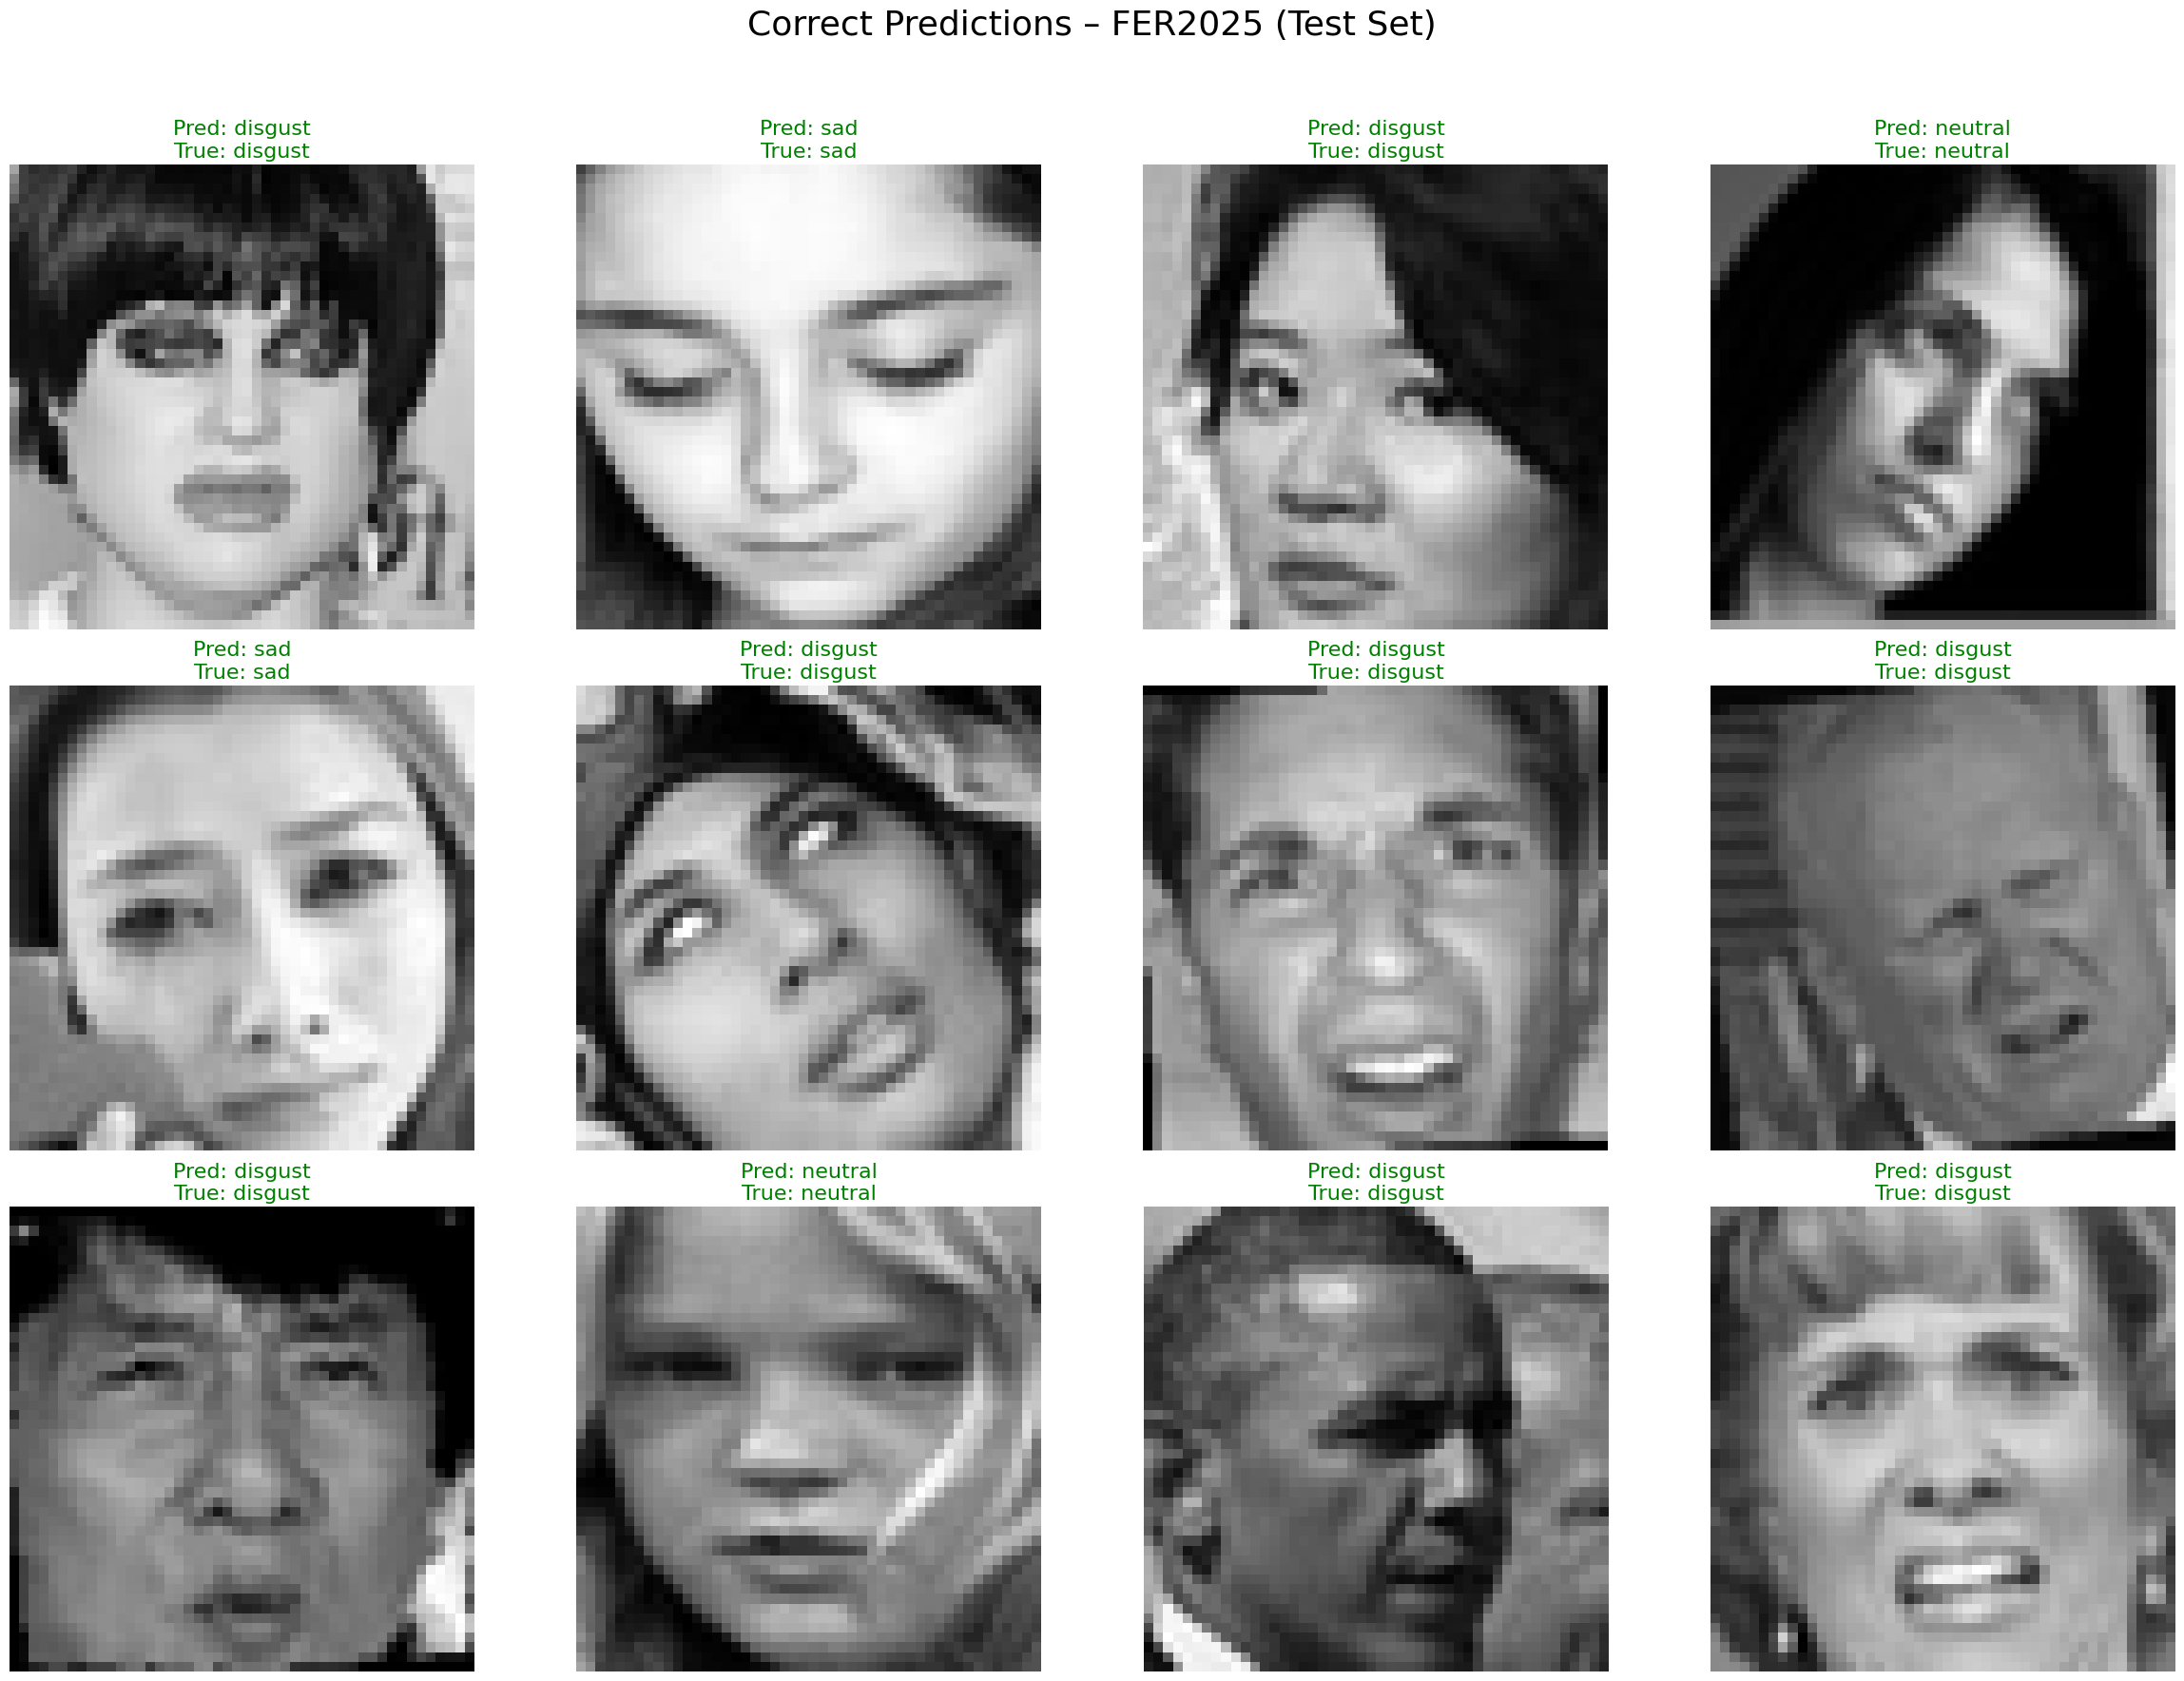

In [ ]:
show_correct_predictions(images_all, y_true, y_pred, classes, n=12)


In [ ]:
import matplotlib.pyplot as plt
import random

def show_wrong_predictions(images, y_true, y_pred, classes, n=12):
    idxs = random.sample(wrong_idx, n)

    rows = 3
    cols = 4

    plt.figure(figsize=(24, 18))

    for i, idx in enumerate(idxs):
        img = images[idx].squeeze()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        plt.title(
            f"Pred: {classes[y_pred[idx]]}\nTrue: {classes[y_true[idx]]}",
            color="red",
            fontsize=16
        )

    plt.suptitle("Wrong Predictions – FER2025 (Test Set)", fontsize=26)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


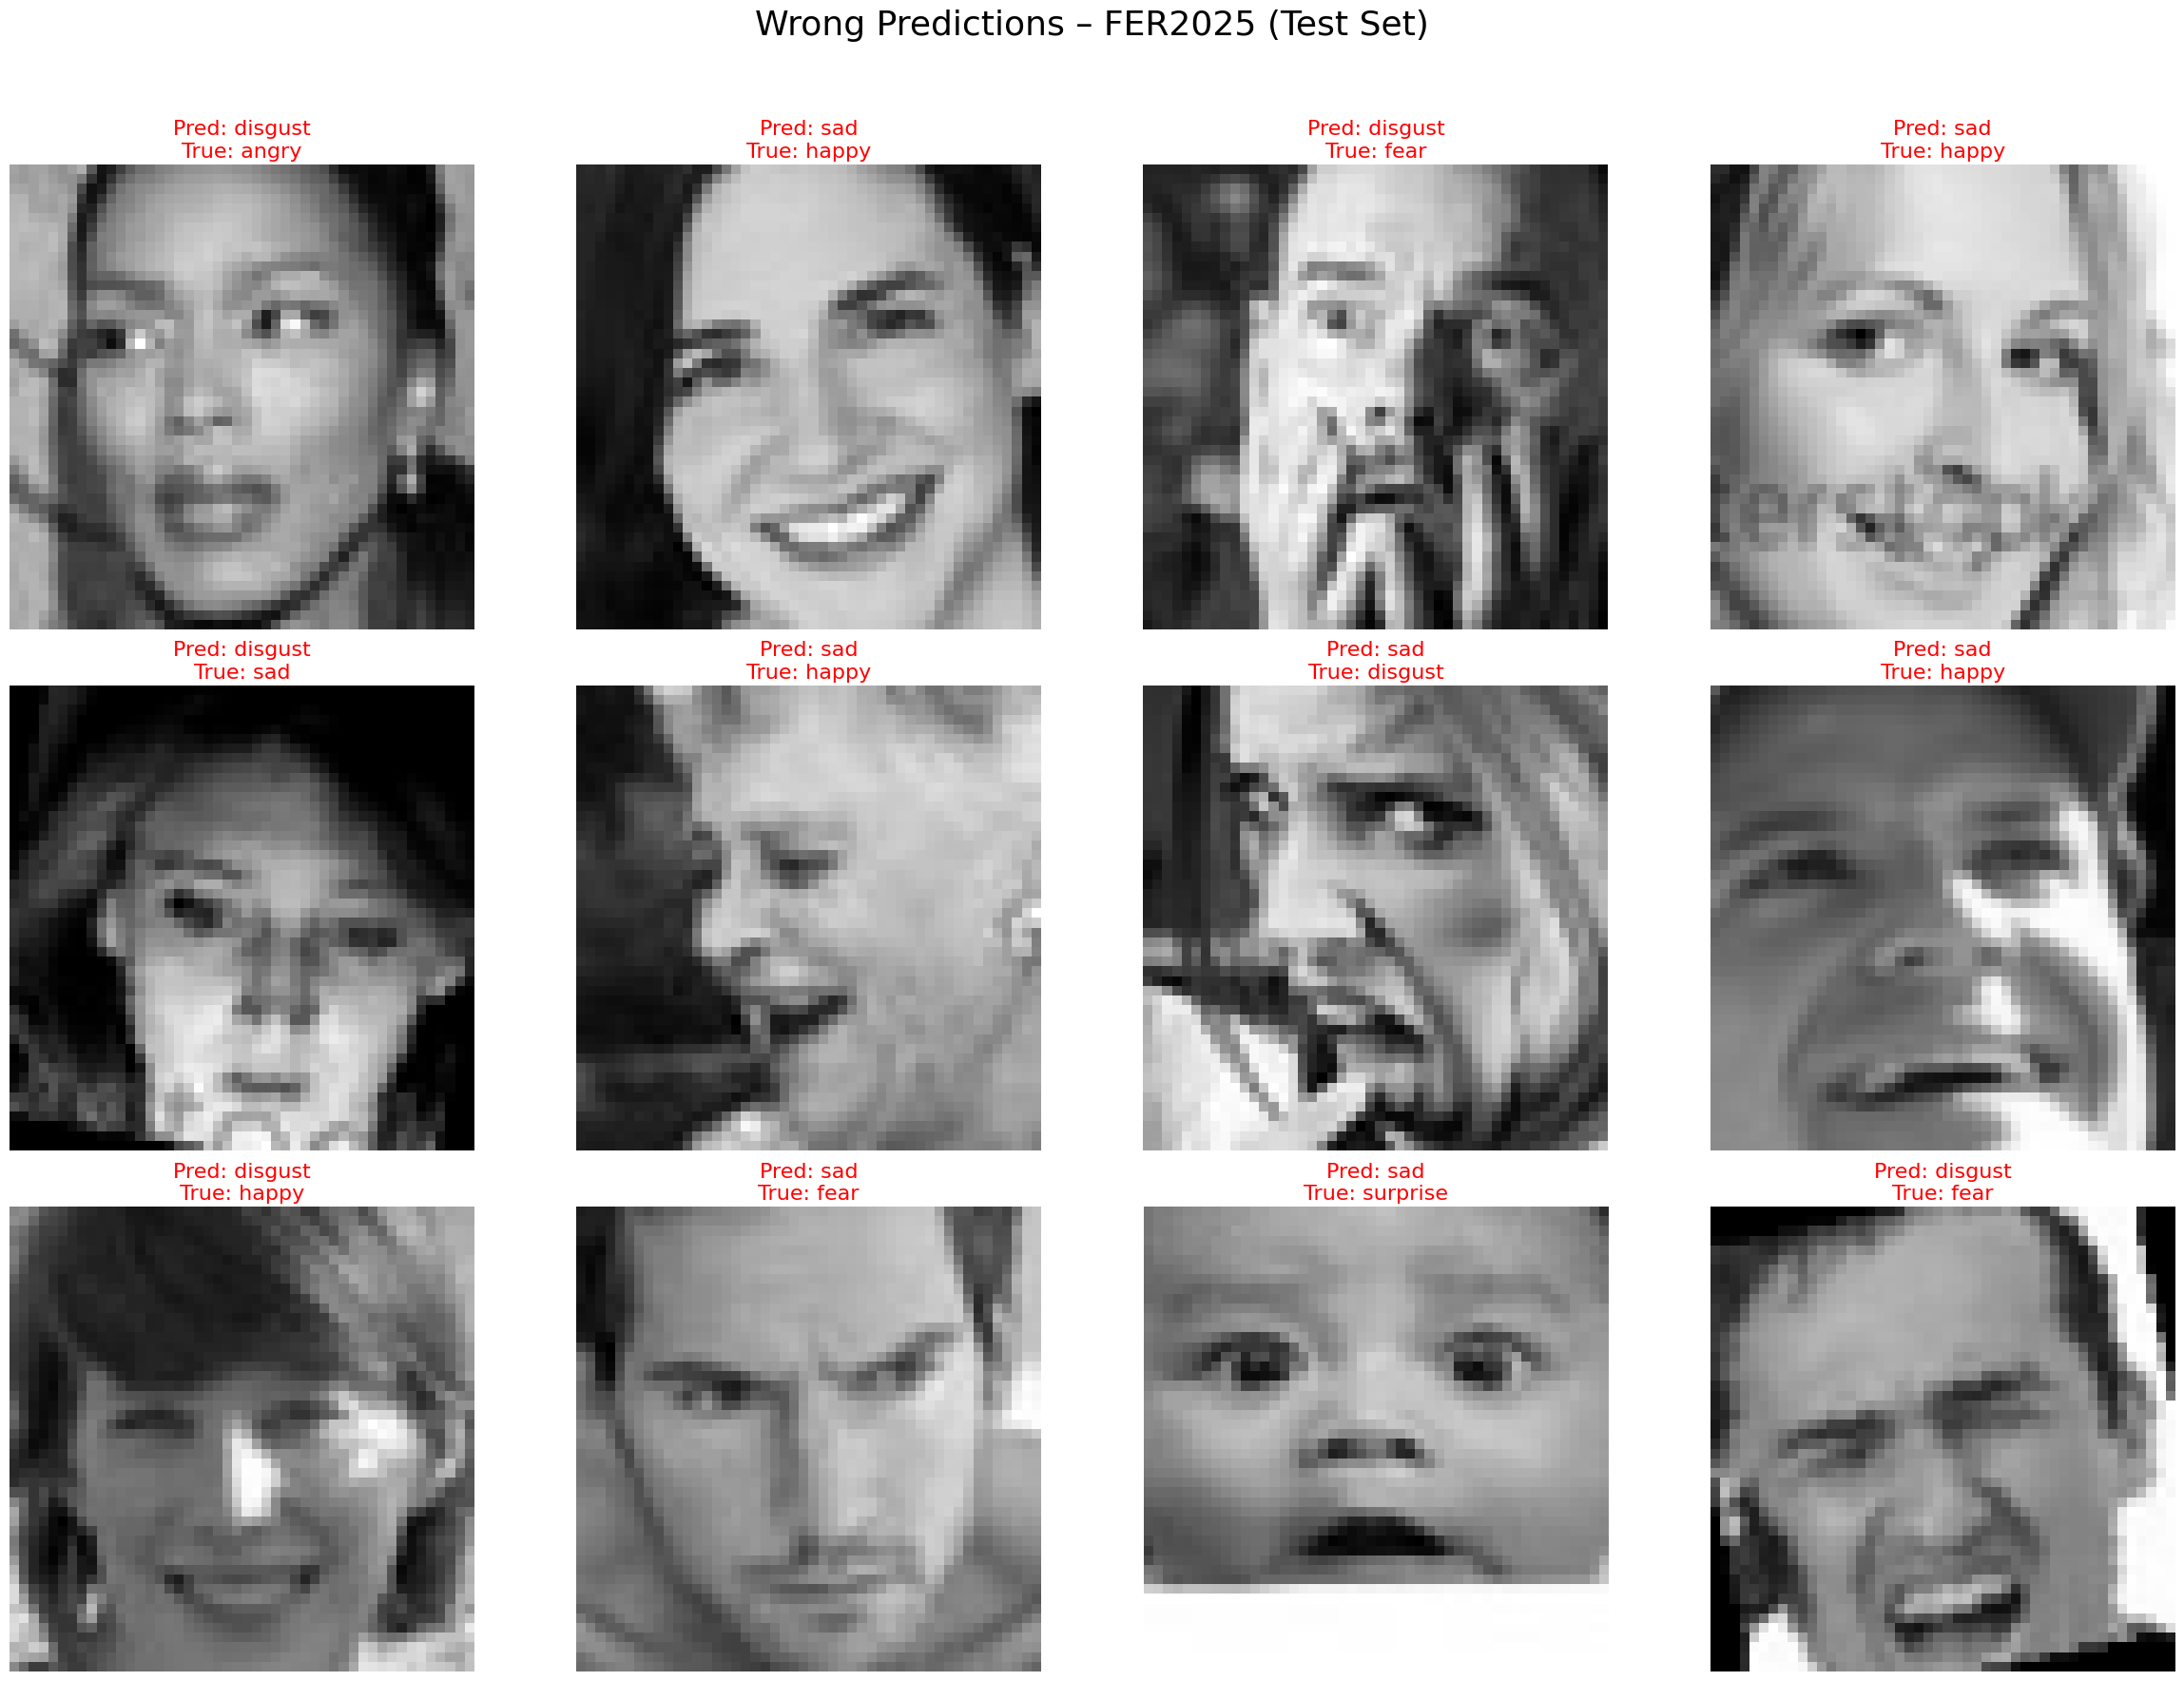

In [ ]:
show_wrong_predictions(images_all, y_true, y_pred, classes, n=12)


In [1]:
!pip install -q nbformat nbconvert

In [ ]:
import nbformat

path = "/content/EmotionDetection4.ipynb"

nb = nbformat.read(path, as_version=4)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, path)

print("Notebook fixed!")

In [3]:
!ls /content

sample_data


In [4]:
from google.colab import files
files.upload()

Saving EmotionDetection4.ipynb to EmotionDetection4.ipynb


{'EmotionDetection4.ipynb': b'{\n  "cells": [\n    {\n      "cell_type": "code",\n      "execution_count": null,\n      "metadata": {\n        "id": "UcgV-gelpDyu"\n      },\n      "outputs": [],\n      "source": [\n        "# ---------------------------------------------\\n",\n        "# 1. IMPORT LIBRARIES\\n",\n        "# ---------------------------------------------\\n",\n        "import os\\n",\n        "import random\\n",\n        "import numpy as np\\n",\n        "import matplotlib.pyplot as plt\\n",\n        "import torch\\n",\n        "import time\\n",\n        "import json\\n",\n        "import contextlib\\n",\n        "import shutil\\n",\n        "import tarfile\\n",\n        "import hashlib\\n",\n        "from pathlib import Path\\n",\n        "\\n",\n        "from torchvision import datasets, transforms\\n",\n        "from torch.utils.data import DataLoader\\n",\n        "from torchvision.transforms import InterpolationMode\\n",\n        "import torch.nn as nn\\n",\n      

In [5]:
!ls /content

EmotionDetection4.ipynb  sample_data


In [6]:
import nbformat

notebook_path = "/content/EmotionDetection4.ipynb"

nb = nbformat.read(notebook_path, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, notebook_path)

print("Notebook cleaned successfully!")

Notebook cleaned successfully!


In [7]:
import nbformat

path = "/content/EmotionDetection4.ipynb"

nb = nbformat.read(path, as_version=4)

# remove broken widgets metadata completely
nb.metadata.pop("widgets", None)

nbformat.write(nb, path)

print("Fixed: metadata.widgets removed")

Fixed: metadata.widgets removed


In [8]:
nb = nbformat.read("/content/EmotionDetection4.ipynb", as_version=4)
print("widgets" in nb.metadata)

False
